# 深層生成モデル　第8回演習

本演習では，**Flow Matching**を実装し，第7回で扱ったDDPMとの比較を行います．
今回はOT-FM[[1]](https://arxiv.org/abs/2210.02747)と呼ばれる種類のFlow Matchingを実装します．
さらに，OT-CFM[[2]](https://arxiv.org/abs/2302.00482)と呼ばれる変種についても実装・比較を行います．

## 準備

In [ ]:
!pip install torchcfm

In [ ]:
%matplotlib inline

from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt

from typing import List, Tuple, Callable

rng = np.random.RandomState(1234)
random_state = 42

## 2次元データでの実装
まずは軌道を可視化しやすくするために，独自に定義する2次元データを用いてFlow Matchingを実装します．

### データの定義

In [ ]:
def generate_train_data(num_samples: int) -> np.array:
  """
  学習データを生成するための関数

  Parameters
  ----------
  num_samples : int
    生成するデータの個数

  Returns
  ----------
  samples : np.ndarray (num_samples, 2)
    生成されたデータ
  """
  center = np.random.randint(0, 8, size=(num_samples,))
  mean = 2 * np.stack([np.cos(np.pi/4 * center), np.sin(np.pi/4 * center)], axis=1)
  epsilon = np.random.multivariate_normal(np.zeros(2), np.eye(2), size=(num_samples,))
  samples = mean + 0.2 * epsilon
  return samples


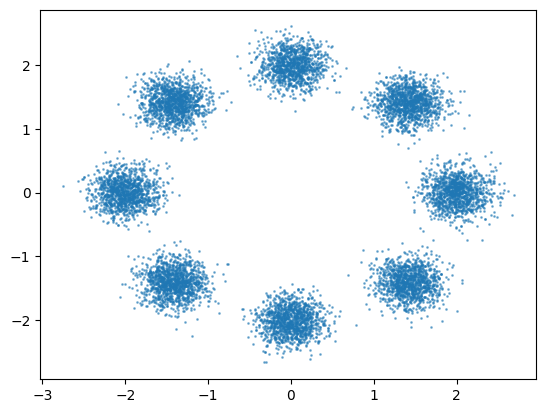

In [ ]:
# 学習データを可視化してみる

train_samples = generate_train_data(10000)

plt.scatter(train_samples[:,0], train_samples[:,1], s=1, alpha=0.5)


### 軌道の定義
次に，DDPM，OT-FM(Flow Matching)それぞれの軌道を定義します．
$x_0, x_1$をそれぞれノイズとデータとした時に，$x_t (t\in[0,1])$はそれぞれ次のように表されます．

DDPM:
$$
x_t = \sqrt{\alpha_t} x_1 + \sqrt{1-\alpha_t} x_0 \\
\alpha_t = \Pi_{i=1}^t 1-\beta_i
$$
(第7回の演習の表記と時刻が反転していることに注意してください！)

OT-FM:
$$
x_t = t x_1 + (1-(1-\sigma_{\mathrm{min}})t) x_0
$$

これらの式を関数として実装します．

In [ ]:
SIGMA_MIN = 0.01


def ddpm_path(x1: torch.Tensor, x0: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
  """
  DDPMの軌道を計算する関数

  Parameters
  ----------
  x1 : torch.Tensor (N, 2)
    N個のデータ
  x0 : torch.Tensor (N, 2)
    N個のノイズ
  t : torch.Tensor (N, 1)
    N個の時刻．[0,1]の値を取る．

  Returns
  ----------
  x_t : torch.Tensor (N, 2)
    計算された時刻 t におけるサンプル
  """
  beta_start = 0.02
  beta_end = 1e-4

  betas = torch.linspace(beta_end, beta_start, 1000).to(x1.device)
  alphas_cumprod = torch.cumprod(1-betas, dim=0).flip(dims=[0])

  t = (t * 999).long()  # alphas_cumprod が長さ1000の配列として定義されているため，t を0～999の値を取る整数型に変換する
  x_t = alphas_cumprod[t].sqrt() * x1 + (1-alphas_cumprod[t]).sqrt() * x0
  return x_t


def otfm_path(x1: torch.Tensor, x0: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
  """
  OT-FMの軌道を計算する関数

  Parameters
  ----------
  x1 : torch.Tensor (N, 2)
    N個のデータ
  x0 : torch.Tensor (N, 2)
    N個のノイズ
  t : torch.Tensor (N, 1)
    N個の時刻．[0,1]の値を取る．

  Returns
  ----------
  x_t : torch.Tensor (N, 2)
    計算された時刻 t におけるサンプル
  """
  x_t = # WRITE ME
  return x_t


### 学習
次に，学習ループを定義します．

学習するニューラルネットは，SiLU (Swish)を活性化関数とした4層の全結合層で構成します．ニューラルネットの入力は2次元座標+時刻 (3次元ベクトル)，出力は予測したノイズまたはベクトル場 (2次元ベクトル)になります．

DDPM, OT-FMそれぞれの損失関数は以下になります．

DDPM:
$$
  \mathbb{E}_{x_1,x_0,t} \left[ \| \epsilon_\theta(x_t,t) - \epsilon \|^2_2 \right]
$$

OT-FM:
$$
  \mathbb{E}_{x_1,x_0,t} \left[ \| v_\theta(x_t,t) - u_t(x_t|x_1) \|^2_2 \right] \\
  u_t(x_t|x_1) = -\frac{1-\sigma_{\mathrm{min}}}{1-(1-\sigma_{\mathrm{min}})t}(x_t - tx_1) + x_1
$$
ただし，$x_t=tx_1 + (1-(1-\sigma_{\mathrm{min}})t)x_0$の時には，$u_t(x_t|x_1)=x_1-(1-\sigma_{\mathrm{min}})x_0$とさらにシンプルな式で計算することができます．

In [ ]:
def train(total_iters: int, batch_size: int, hidden_dim: int, objective: str = "ddpm") -> torch.nn.Module:
  """
  学習を行う関数

  Parameters
  ----------
  total_iters : int
    総iteration数
  batch_size : int
    バッチサイズ
  hidden_dim : int
    ニューラルネットの隠れ次元数
  objective : str
    DDPMとOT-FMのどちらで学習させるか
    "ddpm" または "otfm" のどちらかの値をとる

  Returns
  ----------
  model : nn.Module
    学習されたニューラルネット
  """

  assert objective in ["ddpm", "otfm"], "objective should be either of 'ddpm' or 'otfm'."

  # モデルの定義
  model = nn.Sequential(
      nn.Linear(2 + 1, hidden_dim),    # (x,y)座標と時刻情報を入力に取る
      nn.SiLU(),
      nn.Linear(hidden_dim, hidden_dim),
      nn.SiLU(),
      nn.Linear(hidden_dim, hidden_dim),
      nn.SiLU(),
      nn.Linear(hidden_dim, 2),
  ).to("cuda")

  optimizer = optim.Adam(model.parameters(), lr=1e-3)

  # 学習ループ
  for iter in range(total_iters+1):
    x1_np = generate_train_data(batch_size)
    x1 = torch.from_numpy(x1_np).float().to("cuda")
    x0 = torch.randn_like(x1)
    t = torch.rand((batch_size, 1)).to("cuda")

    if objective == "ddpm":
      xt = ddpm_path(x1, x0, t)
    elif objective == "otfm":
      xt = otfm_path(x1, x0, t)

    input = torch.cat([xt, t], dim=1)
    pred = model(input)

    if objective == "ddpm":
      target = x0
    elif objective == "otfm":
      target = # WRITE ME

    loss = F.mse_loss(pred, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 1000 == 0:
      print(f"[Iter] {iter}   [Loss] {loss.item():.5f}")

  return model


In [ ]:
# DDPM の学習
model_ddpm = train(
    total_iters=10000,
    batch_size=64,
    hidden_dim=256,
    objective="ddpm",
)


[Iter] 0   [Loss] 1.02725
[Iter] 1000   [Loss] 0.27232
[Iter] 2000   [Loss] 0.41925
[Iter] 3000   [Loss] 0.39608
[Iter] 4000   [Loss] 0.32951
[Iter] 5000   [Loss] 0.23213
[Iter] 6000   [Loss] 0.24874
[Iter] 7000   [Loss] 0.31536
[Iter] 8000   [Loss] 0.30404
[Iter] 9000   [Loss] 0.31461
[Iter] 10000   [Loss] 0.31878


In [ ]:
# OT-FM の学習
model_otfm = train(
    total_iters=10000,
    batch_size=64,
    hidden_dim=256,
    objective="otfm",
)


[Iter] 0   [Loss] 3.18855
[Iter] 1000   [Loss] 1.87889
[Iter] 2000   [Loss] 2.32795
[Iter] 3000   [Loss] 1.81516
[Iter] 4000   [Loss] 2.45581
[Iter] 5000   [Loss] 1.55182
[Iter] 6000   [Loss] 1.53251
[Iter] 7000   [Loss] 2.13887
[Iter] 8000   [Loss] 1.73920
[Iter] 9000   [Loss] 1.75472
[Iter] 10000   [Loss] 1.93067


### 可視化
次に，学習させたそれぞれのモデルによるサンプリングを可視化してみましょう．

まず，サンプリングを行う関数を定義します．
DDPMの方では，DDIMというサンプリング手法を用います．
DDIMのサンプリングは以下の式によって行われます．(参照: [[3]](https://arxiv.org/abs/2010.02502) 12式の$\sigma_t=0$の場合)

$$
x_{t+\Delta t} = \sqrt{\alpha_{t+\Delta t}}\left( \frac{x_t-\sqrt{1-\alpha_t}\epsilon_\theta(x_t)}{\sqrt{\alpha_t}} \right) + \sqrt{1-\alpha_{t+\Delta t}}\epsilon_\theta(x_t)
$$

OT-FMの方では，オイラー法を用います．
オイラー法では以下の式によって$x_t$が更新されます．
$$
x_{t+\Delta t} = x_t + \Delta t \, v_\theta(x_t)
$$

In [ ]:
@torch.no_grad()
def ddpm_sampling(model: nn.Module, x0: torch.Tensor, num_sampling_steps: int) -> torch.Tensor:
  """
  DDPMのサンプリングを行う関数

  Parameters
  ----------
  model : nn.Module
    学習されたニューラルネット
  x0 : torch.Tensor (N, 2)
    N個のサンプリング初期値
  num_sampling_steps : int
    サンプリングにかけるステップ数

  Returns
  ----------
  traj : List[ torch.Tensor (N, 2) ]
    N個のデータのサンプリング軌道
  """
  beta_start = 0.02
  beta_end = 1e-4

  betas = torch.linspace(beta_end, beta_start, 1000).to(x0.device)
  alphas_cumprod = torch.cumprod(1-betas, dim=0).flip(dims=[0])

  traj = [x0.to("cpu").clone()]

  xt = x0.clone()
  t = torch.zeros((xt.shape[0], 1)).to(x0.device)
  delta_t = 1 / num_sampling_steps

  for i in range(num_sampling_steps):
    epsilon_pred = model(torch.cat([xt, t], dim=1))

    beta_t = betas[(t*999).long()]
    alpha_cumprod_t = alphas_cumprod[(t*999).long()]
    x0_pred = (xt - (1-alpha_cumprod_t).sqrt() * epsilon_pred) / alpha_cumprod_t.sqrt()

    t += delta_t

    beta_t_next = betas[(t*999).long()]
    alpha_cumprod_t_next = alphas_cumprod[(t*999).long()]
    xt = alpha_cumprod_t_next.sqrt() * x0_pred + (1-alpha_cumprod_t_next).sqrt() * epsilon_pred

    traj.append(xt.to("cpu").clone())

  return torch.stack(traj)


@torch.no_grad()
def otfm_sampling(model: nn.Module, x0: torch.Tensor, num_sampling_steps: int) -> torch.Tensor:
  """
  OT-FMのサンプリングを行う関数

  Parameters
  ----------
  model : nn.Module
    学習されたニューラルネット
  x0 : torch.Tensor (N, 2)
    N個のサンプリング初期値
  num_sampling_steps : int
    サンプリングにかけるステップ数

  Returns
  ----------
  traj : List[ torch.Tensor (N, 2) ]
    N個のデータのサンプリング軌道
  """

  traj = [x0.to("cpu").clone()]

  xt = x0.clone()
  t = torch.zeros((xt.shape[0], 1)).to(x0.device)
  delta_t = 1 / num_sampling_steps

  for i in range(num_sampling_steps):
    vt_pred = model(torch.cat([xt, t], dim=1))

    xt += # WRITE ME
    t += 1 / num_sampling_steps

    traj.append(xt.to("cpu").clone())

  return torch.stack(traj)


(-3.0, 3.0)

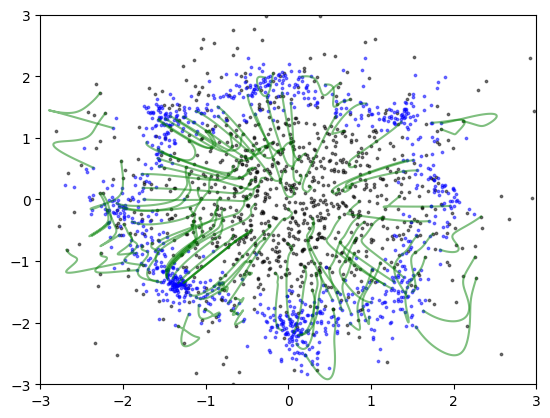

In [ ]:
# DDPM の結果の可視化

x = torch.randn(1000, 2).to("cuda")
traj = ddpm_sampling(model_ddpm, x, 100)

plt.scatter(traj[0,:,0], traj[0,:,1], s=3, alpha=0.5, c="black")   # x0をプロット
plt.scatter(traj[-1,:,0], traj[-1,:,1], s=3, alpha=0.5, c="blue")  # x1をプロット

for i in range(100):
  plt.plot(traj[:,i,0], traj[:,i,1], alpha=0.5, c="green")   # xtをプロット(最初の100個だけ)

plt.xlim([-3, 3])
plt.ylim([-3, 3])

(-3.0, 3.0)

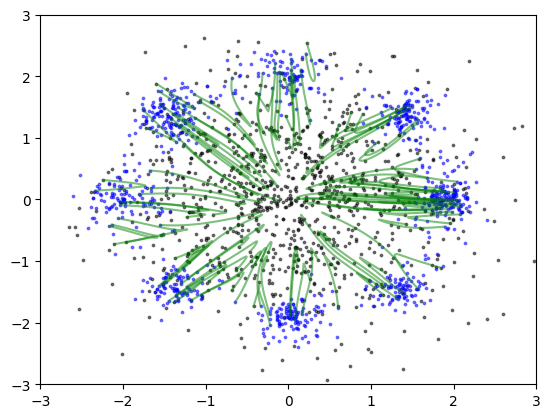

In [ ]:
# OT-FM の結果の可視化

x = torch.randn(1000, 2).to("cuda")
traj = otfm_sampling(model_otfm, x, 100)

plt.scatter(traj[0,:,0], traj[0,:,1], s=3, alpha=0.5, c="black")   # x0をプロット
plt.scatter(traj[-1,:,0], traj[-1,:,1], s=3, alpha=0.5, c="blue")  # x1をプロット

for i in range(100):
  plt.plot(traj[:,i,0], traj[:,i,1], alpha=0.5, c="green")   # xtをプロット(最初の100個だけ)

plt.xlim([-3, 3])
plt.ylim([-3, 3])

## OT-CFMの実装
次に，OT-CFMと呼ばれる種類のFlow Matchingを実装・学習させてみます．

OT-FMでは条件付きベクトル場が最適輸送パスになるように定式化していました．
しかし，実際に学習されるベクトル場は周辺化されたものになり，その周辺ベクトル場が最適輸送パスになることは保証されません．
周辺ベクトル場を最適輸送パスにするためには，データセット全体と(学習中にサンプリングされる)ノイズ全体との最適輸送を計算する必要がありますが，多大な計算量がかかります．

そこで，OT-CFMでは，ミニバッチ単位での周辺ベクトル場が最適輸送パスになるようにします．
OT-CFMでも学習される周辺ベクトル場が最適輸送パスになるとは限りませんが，OT-FMよりは最適輸送パスに近くなることが期待できます．

### 最適輸送カップリングの計算
OT-CFMの実装のために，「ミニバッチ単位での最適輸送」を計算する必要があります．
データのミニバッチを$(x^0_1, x^1_1, \cdots, x^n_1)$とし，ノイズのミニバッチを$(x^0_0, x^1_0, \cdots, x^n_0)$とします．
この時，ミニバッチ単位の最適輸送は次の線形計画問題として定式化されます．
$$
\min_{P} \sum_{i,j=0}^n P_{i,j} C_{i,j} \quad
s.t. \sum_{i=0}^n P_{i,j} = \sum_{j=0}^n P_{i,j}=1
$$
ただし，$C_{i,j} = \| x^i_1-x^j_0 \|^2_2$ です．

これは線形割当問題という種類の問題になり(一般的には線形計画問題)，適当なライブラリのソルバーを用いて解くことができます．

最適輸送に関する日本語の解説記事としては，[[4]](https://www.slideshare.net/slideshow/ss-249394573/249394573)がわかりやすいです．
詳細はこちらを参照してください．

In [ ]:
# ミニバッチ単位での最適輸送を計算する

from scipy.optimize import linear_sum_assignment

@torch.no_grad()
def calc_minibatch_ot(x1: torch.Tensor, x0: torch.Tensor):
  N = x1.shape[0]
  cost = (x1.reshape(N, 1, 2) - x0.reshape(1, N, 2)).pow(2).sum(2)  # (N, N)の行列
  row_id, col_id = linear_sum_assignment(cost.to("cpu").numpy())
  x0 = x0[col_id]
  return x0


In [ ]:
def train_otcfm(total_iters: int, batch_size: int, hidden_dim: int) -> torch.nn.Module:
  """
  学習を行う関数

  Parameters
  ----------
  total_iters : int
    総iteration数
  batch_size : int
    バッチサイズ
  hidden_dim : int
    ニューラルネットの隠れ次元数

  Returns
  ----------
  model : nn.Module
    学習されたニューラルネット
  """

  # モデルの定義
  model = nn.Sequential(
      nn.Linear(2 + 1, hidden_dim),    # (x,y)座標と時刻情報を入力に取る
      nn.SiLU(),
      nn.Linear(hidden_dim, hidden_dim),
      nn.SiLU(),
      nn.Linear(hidden_dim, hidden_dim),
      nn.SiLU(),
      nn.Linear(hidden_dim, 2),
  ).to("cuda")

  optimizer = optim.Adam(model.parameters(), lr=1e-3)

  # 学習ループ
  for iter in range(total_iters+1):
    x1_np = generate_train_data(batch_size)
    x1 = torch.from_numpy(x1_np).float().to("cuda")
    x0 = torch.randn_like(x1)
    t = torch.rand((batch_size, 1)).to("cuda")

    x0 = calc_minibatch_ot(x1, x0)

    xt = otfm_path(x1, x0, t)

    input = torch.cat([xt, t], dim=1)
    pred = model(input)

    target = x1 - (1-SIGMA_MIN) * x0
    loss = F.mse_loss(pred, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 1000 == 0:
      print(f"[Iter] {iter}   [Loss] {loss.item():.5f}")

  return model


In [ ]:
# OT-CFM の学習
model_otcfm = train_otcfm(
    total_iters=10000,
    batch_size=64,
    hidden_dim=256,
)


[Iter] 0   [Loss] 0.49544
[Iter] 1000   [Loss] 0.17622
[Iter] 2000   [Loss] 0.11252
[Iter] 3000   [Loss] 0.12710
[Iter] 4000   [Loss] 0.20595
[Iter] 5000   [Loss] 0.19516
[Iter] 6000   [Loss] 0.11378
[Iter] 7000   [Loss] 0.14511
[Iter] 8000   [Loss] 0.18653
[Iter] 9000   [Loss] 0.11139
[Iter] 10000   [Loss] 0.16753


(-3.0, 3.0)

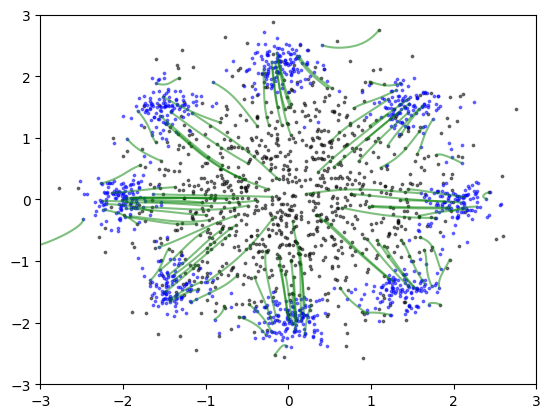

In [ ]:
# OT-CFM の結果の可視化 (OT-FMよりは軌道が直線に近くなる)

x = torch.randn(1000, 2).to("cuda")
traj = otfm_sampling(model_otcfm, x, 100)

plt.scatter(traj[0,:,0], traj[0,:,1], s=3, alpha=0.5, c="black")   # x0をプロット
plt.scatter(traj[-1,:,0], traj[-1,:,1], s=3, alpha=0.5, c="blue")  # x1をプロット

for i in range(100):
  plt.plot(traj[:,i,0], traj[:,i,1], alpha=0.5, c="green")   # xtをプロット(最初の100個だけ)

plt.xlim([-3, 3])
plt.ylim([-3, 3])

## 画像データでの実装
最後に，CIFAR-10でDDPMとOT-FMをそれぞれ学習させてみます．

### データの読み込み

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

batch_size = 128

train_dataset = datasets.CIFAR10(
    './data/CIFAR10', train=True, download=True, transform=transform
)
valid_dataset = datasets.CIFAR10(
    './data/CIFAR10', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=batch_size, shuffle=False
)

### 学習
ニューラルネットは第7回の演習同様，Attentionを含んだU-Netを用います．
コードを簡潔にするために，ここでは`torchcfm`というライブラリで定義されているU-Netを呼び出します．

In [ ]:
from torchcfm.models.unet import UNetModel

In [ ]:
from tqdm.notebook import tqdm


def train_cifar(total_epochs: int, objective: str = "ddpm") -> torch.nn.Module:

  assert objective in ["ddpm", "otfm"], "objective should be either of 'ddpm' or 'otfm'."

  # モデルの定義
  model = UNetModel(
      dim=(3, 32, 32),
      num_channels=128,
      num_res_blocks=2,
      channel_mult=(1,2,2,2),
  ).to("cuda")

  optimizer = optim.Adam(model.parameters(), lr=1e-3)

  # 学習ループ
  for epoch in range(total_epochs):
    train_loss = 0

    for x1, label in tqdm(train_loader):
      x1 = x1.to("cuda")
      x0 = torch.randn_like(x1)
      t = torch.rand((x1.shape[0], 1, 1, 1)).to("cuda")

      if objective == "ddpm":
        xt = ddpm_path(x1, x0, t)
      elif objective == "otfm":
        xt = otfm_path(x1, x0, t)

      pred = model(t.flatten(), xt)

      if objective == "ddpm":
        target = x0
      elif objective == "otfm":
        target = x1 - (1-SIGMA_MIN) * x0

      loss = F.mse_loss(pred, target)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_loss += loss.item()

    print(f"[Epoch] {epoch}   [Loss] {train_loss / len(train_loader)}")

  return model


In [ ]:
# CIFAR での学習

num_epochs = 1 # 3

model_cifar_ddpm = train_cifar(total_epochs=num_epochs, objective="ddpm")
model_cifar_otfm = train_cifar(total_epochs=num_epochs, objective="otfm")


[Epoch] 0   [Loss] 0.07283926854753281
[Epoch] 0   [Loss] 0.2825115587171691


### サンプリング過程の可視化
$t=0,0.2,0.4,0.6,0.8,1$の時点での生成画像を表示してみます．

In [ ]:
# サンプリングの関数をUNet用に再定義

@torch.no_grad()
def cifar_ddpm_sampling(model: nn.Module, x0: torch.Tensor, num_sampling_steps: int) -> torch.Tensor:
  beta_start = 0.02
  beta_end = 1e-4

  betas = torch.linspace(beta_end, beta_start, 1000).to(x0.device)
  alphas_cumprod = torch.cumprod(1-betas, dim=0).flip(dims=[0])

  traj = [x0.to("cpu").clone()]

  xt = x0.clone()
  t = torch.zeros((xt.shape[0], 1, 1, 1)).to(x0.device)
  delta_t = 1 / num_sampling_steps

  for i in range(num_sampling_steps):
    epsilon_pred = model(t.reshape(-1), xt)

    beta_t = betas[(t*999).long()]
    alpha_cumprod_t = alphas_cumprod[(t*999).long()]
    x0_pred = (xt - (1-alpha_cumprod_t).sqrt() * epsilon_pred) / alpha_cumprod_t.sqrt()

    t += delta_t

    beta_t_next = betas[(t*999).long()]
    alpha_cumprod_t_next = alphas_cumprod[(t*999).long()]
    xt = alpha_cumprod_t_next.sqrt() * x0_pred + (1-alpha_cumprod_t_next).sqrt() * epsilon_pred

    traj.append(xt.to("cpu").clone())

  return torch.stack(traj)


@torch.no_grad()
def cifar_otfm_sampling(model: nn.Module, x0: torch.Tensor, num_sampling_steps: int) -> torch.Tensor:
  traj = [x0.to("cpu").clone()]

  xt = x0.clone()
  t = torch.zeros((xt.shape[0], 1, 1, 1)).to(x0.device)
  delta_t = 1 / num_sampling_steps

  for i in range(num_sampling_steps):
    vt_pred = model(t.reshape(-1), xt)

    xt += delta_t * vt_pred
    t += 1 / num_sampling_steps

    traj.append(xt.to("cpu").clone())

  return torch.stack(traj)


In [ ]:
# DDPMで4枚ずつ生成する

model_cifar_ddpm.eval()

generator = torch.Generator()
generator.manual_seed(0)

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
  x0 = torch.randn(1, 3, 32, 32, generator=generator).to("cuda")
  cifar_ddpm_traj = cifar_ddpm_sampling(model_cifar_ddpm, x0, 100)
  for j, t_index in enumerate([0, 20, 40, 60, 80, 99]):
    image = cifar_ddpm_traj[t_index][0].permute(1,2,0)
    image = torch.clip(image*0.5+0.5, 0, 1)  # [-1,1]の範囲を[0,1]の範囲にクリッピング
    axes[i*6+j].imshow(image)
    axes[i*6+j].axis("off")

    if i == 0:
        axes[i*6+j].set_title(f"t={t_index/100:.2f}")


In [ ]:
# OT-FMで4枚ずつ生成する

model_cifar_otfm.eval()

generator = torch.Generator()
generator.manual_seed(0)

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
  x0 = torch.randn(1, 3, 32, 32, generator=generator).to("cuda")
  cifar_otfm_traj = cifar_otfm_sampling(model_cifar_otfm, x0, 100)
  for j, t_index in enumerate([0, 20, 40, 60, 80, 99]):
    image = cifar_otfm_traj[t_index][0].permute(1,2,0)
    image = torch.clip(image*0.5+0.5, 0, 1)  # [-1,1]の範囲を[0,1]の範囲にクリッピング
    axes[i*6+j].imshow(image)
    axes[i*6+j].axis("off")

    if i == 0:
        axes[i*6+j].set_title(f"t={t_index/100:.2f}")


# 参考文献
[[1]](https://arxiv.org/abs/2210.02747) Lipman et al., 2022, "Flow matching for generative modeling." arXiv:2210.02747.

[[2]](https://arxiv.org/abs/2302.00482) Tong et al., 2023, "Improving and generalizing flow-based generative models with minibatch optimal transport." arXiv:2302.00482.

[[3]](https://arxiv.org/abs/2010.02502) Song et al., 2022, "Denoising diffusion implicit models." arXiv:2010.02502

[[4]](https://www.slideshare.net/slideshow/ss-249394573/249394573) 佐藤竜馬, 2021, "最適輸送の解き方." https://www.slideshare.net/slideshow/ss-249394573/249394573
